# Baseline models

Goal: Make baseline predictions by averaging rain, crop, and surplus data over the entire basin for a single site.
Currently using site WQS0039 but can be updated to any uid.

To do:
- Compare nitrate to average over day instead of max for linear regression (DONE)
- Create surplus x rain data per day by using the surplus data in 2017 at each grid (needs grid_id added to rain data) (DONE)
- Explore different features more, determine if any are good. (Surplus x rain seems to be best right now)
- Additional EDA beyond pair plot, test with other basins
- Create baseline model for multiple sites and test on a separate site

In [18]:
import sys
sys.path.insert(0, "../") # replace with path/to/project/root
from data import get_data, get_site_ids

import pandas as pd
import numpy as np


In [19]:
def make_site_df(site):

    data = get_data(site)

    # Daily precipitation
    precip = (
        data.rain
        .groupby("date", as_index=False)["precip_in_1d"]
        .mean()
    )

    # Daily nitrate statistics
    water = (
        data.water
        .resample("1D")["nitrate_con"]
        .agg(
            nitrate_con="mean",
            nitrate_max="max",
        )
        .reset_index(names="date")
        .assign(
            date=lambda x: x["date"].dt.tz_localize(None),
            violation=lambda x: (x["nitrate_max"] > 10).astype(int),
        )
    )

    # Base dataframe
    df = water.merge(precip, on="date", how="left")

    # Crop features
    crops = (
        data.crops
        .groupby("year", as_index=False)
        .sum()
        .drop(columns="node_id", errors="ignore")
    )

    # Surplus N features
    nitrogen_2017 = data.surplus.query("year == 2017")

    surplus_n_2017 = nitrogen_2017["surplus_kgha"].mean()

    rain = (
        data.rain
        .merge(
            data.grid[["node_id", "cell_area", "geometry"]],
            on="node_id",
            how="left",
        )
        .merge(
            nitrogen_2017[["node_id", "surplus_kgha"]],
            on="node_id",
            how="left",
        )
    )

    rain["rain_x_surplus"] = (
        rain["precip_in_1d"] * rain["surplus_kgha"]
    )

    daily_rain_x_surplus = (
        rain.groupby("date", as_index=False)["rain_x_surplus"]
        .mean()
    )

    df = df.merge(daily_rain_x_surplus, on="date", how="left")

    # Rolling rainfall features
    for window in [7, 14, 30]:
        df[f"rain_{window}d"] = (
            df["precip_in_1d"]
            .rolling(window, min_periods=1)
            .sum()
        )

        df[f"rain_x_surplus_{window}d"] = (
            df["rain_x_surplus"]
            .rolling(window, min_periods=1)
            .sum()
        )

    # Yearly crop features
    df["year"] = df["date"].dt.year

    df = df.merge(
        crops,
        on="year",
        how="left",
    )

    # Site-level features
    df["surplus_n_2017"] = surplus_n_2017
    df["site_id"] = site
    df["basin_area"] = data.basin_area

    # Autoregressive features
    df["nitrate_lag1"] = df["nitrate_con"]
    df["nitrate_lag2"] = df["nitrate_con"].shift(1)
    df["nitrate_lag3"] = df["nitrate_con"].shift(2)

    # Targets
    df["nitrate_tomorrow"] = df["nitrate_con"].shift(-1)
    df["violation_tomorrow"] = df["violation"].shift(-1)

    return (
        df
        .dropna(
            subset=[
                "nitrate_tomorrow",
                "nitrate_lag3",
                "nitrate_con",
            ]
        )
        .reset_index(drop=True)
    )

In [20]:
uid = "WQS0039"

df = make_site_df(uid)


In [21]:
# Check seasonality of violations. Indicate that this time series should possibly be handled as periodic/seasonal.

df["month"] = df["date"].dt.month
monthly = df.groupby("month")["violation_tomorrow"].agg(["sum", "count"])
monthly["rate"] = monthly["sum"] / monthly["count"]
print("Violations by month:\n", monthly, "\n")
 
top_month_share = monthly["sum"].max() / monthly["sum"].sum()
print(f"Largest single month holds {top_month_share:.0%} of all violations.")
if top_month_share > 0.35:
    print("WARNING: violations are heavily seasonal. A plain chronological "
          "split may starve some folds of positives -- consider checking "
          "fold-level violation counts below, or stratifying by season "
          "instead of pure date order.\n")
else:
    print("Violations are reasonably spread across the year.\n")


Violations by month:
          sum  count      rate
month                        
3        5.0     10  0.500000
4       26.0     99  0.262626
5       72.0    161  0.447205
6      130.0    186  0.698925
7       53.0    177  0.299435
8       14.0    124  0.112903
9       27.0    149  0.181208
10      63.0    145  0.434483
11      42.0    142  0.295775
12       2.0     26  0.076923 

Largest single month holds 30% of all violations.
Violations are reasonably spread across the year.



## Edit included features here!

In [22]:
cutoff = df["date"].quantile(0.8)          # last ~20% of days held out
train = df[df["date"] <= cutoff]
hold_out  = df[df["date"] >  cutoff]
 
crop_cols = [c for c in crops.columns if c not in ["year", "node_id"]]

# PLAY AROUND HERE WITH DIFFERENT FEATURES TO DETERMINE WHICH ONES YOU WANT TO INCLUDE.
# ALL POSSIBLE FEATURES ARE INCLUDED IN THE commented feature_cols LIST.

# feature_cols = (["precip_in_1d", "rain_7d", "rain_14d", "rain_30d", "surplus_x_rain30",
#                   "nitrate_lag1", "nitrate_lag2", "nitrate_lag3", "rain_x_surplus",
#                    "rain_x_surplus_7d", "rain_x_surplus_14d", "rain_x_surplus_30d"]
#                  + crop_cols)
feature_cols = (["nitrate_lag1", "rain_x_surplus_7d"])
 
X = train[feature_cols].fillna(0).values    # train on all features for training data. Fix null values
y_class = train["violation_tomorrow"].values
y_reg   = train["nitrate_tomorrow"].values
today_value = train["nitrate_con"].values   # needed for the random-walk baseline

 

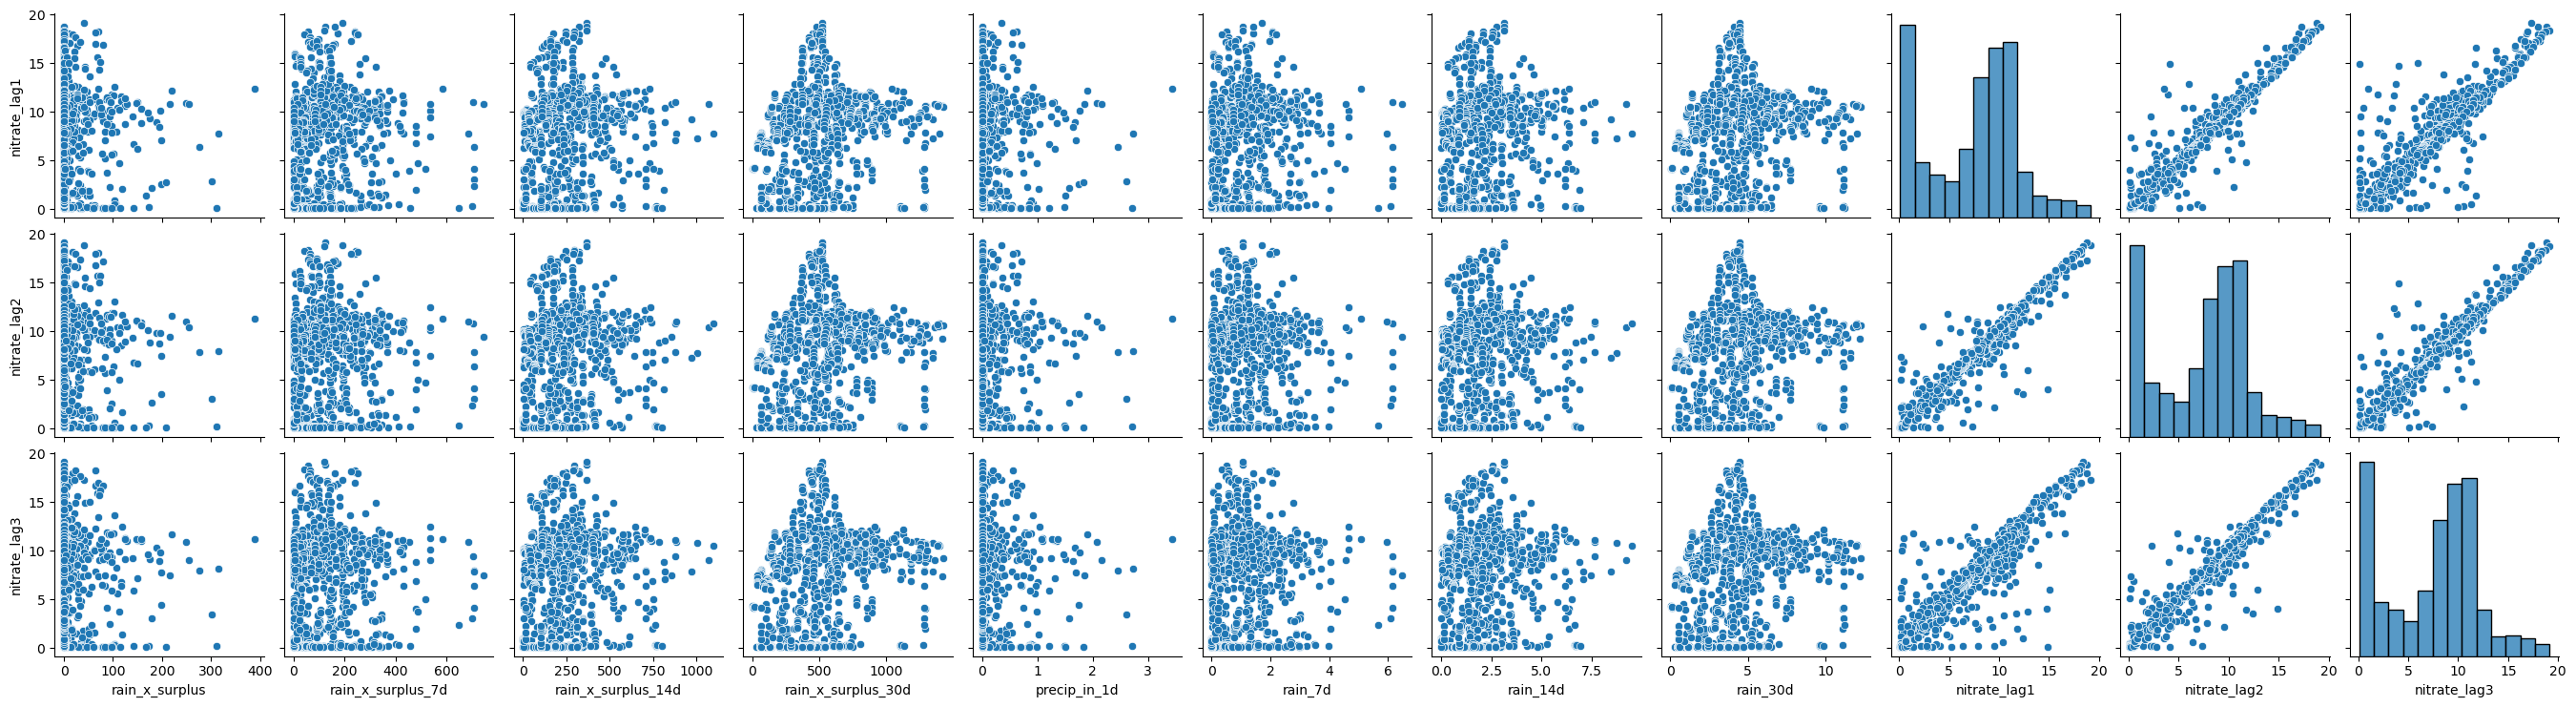

In [23]:
import seaborn as sns

sns.pairplot(train[["rain_x_surplus", "rain_x_surplus_7d", "rain_x_surplus_14d", "rain_x_surplus_30d", "precip_in_1d", "rain_7d", "rain_14d", "rain_30d", "nitrate_lag1","nitrate_lag2","nitrate_lag3"]], y_vars=["nitrate_lag1","nitrate_lag2","nitrate_lag3"])

The remainder is testing different baseline models on the formatted data.

In [24]:
from scipy.stats import norm
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score, mean_absolute_error, mean_squared_error
 

# ------------------------------------------------------------------
# 6. TIME SERIES CROSS-VALIDATION
# TimeSeriesSplit always trains on the past and tests on a later, contiguous
# block -- never shuffles, never tests on data that precedes training data.
# ------------------------------------------------------------------
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=100)
 
results = {k: [] for k in [
    "dummy_most_frequent_AP", "dummy_stratified_AP",
    "gaussian_rw_classifier_AP", "logreg_AP",
    "persistence_regression_MAE", "persistence_regression_RMSE",
    "linreg_MAE", "linreg_RMSE",
]}
 
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    yc_train, yc_test = y_class[train_idx], y_class[test_idx]
    yr_train, yr_test = y_reg[train_idx], y_reg[test_idx]
    today_train, today_test = today_value[train_idx], today_value[test_idx]
 
    print(f"Fold {fold}: train={len(train_idx)}  test={len(test_idx)}  "
          f"test_violations={yc_test.sum()}")
    if yc_test.sum() == 0:
        print("  WARNING: this fold has zero violations -- AP undefined/misleading for it.")
 
    # --- Dummy classifiers (the honest floor) ---
    for strategy, key in [("most_frequent", "dummy_most_frequent_AP"),
                           ("stratified", "dummy_stratified_AP")]:
        dummy = DummyClassifier(strategy=strategy, random_state=0)
        dummy.fit(X_train, yc_train)
        ap = average_precision_score(yc_test, dummy.predict_proba(X_test)[:, 1])
        results[key].append(ap)
 
    # --- Gaussian random walk ---
    # sigma estimated from TRAINING differences only -- no future leakage
    train_diffs = np.diff(today_train)
    sigma = max(np.std(train_diffs), 1e-6) if len(train_diffs) > 1 else 1.0

    # classification view: P(tomorrow > 10 | today) under N(today, sigma^2)
    rw_proba = 1 - norm.cdf((10 - today_test) / sigma)
    results["gaussian_rw_classifier_AP"].append(average_precision_score(yc_test, rw_proba))
 
    # regression view: point forecast = today's value (persistence)
    persistence_pred = today_test
    results["persistence_regression_MAE"].append(mean_absolute_error(yr_test, persistence_pred))
    results["persistence_regression_RMSE"].append(np.sqrt(mean_squared_error(yr_test, persistence_pred)))
 
    # --- Logistic regression (feature-based classification) ---
    logreg = make_pipeline(StandardScaler(),
                            LogisticRegression(class_weight="balanced", max_iter=1000))
    logreg.fit(X_train, yc_train)
    ap_lr = average_precision_score(yc_test, logreg.predict_proba(X_test)[:, 1])
    results["logreg_AP"].append(ap_lr)
 
    # --- Linear regression (feature-based regression) ---
    linreg = make_pipeline(StandardScaler(), LinearRegression())
    linreg.fit(X_train, yr_train)
    lr_pred = linreg.predict(X_test)
    results["linreg_MAE"].append(mean_absolute_error(yr_test, lr_pred))
    results["linreg_RMSE"].append(np.sqrt(mean_squared_error(yr_test, lr_pred)))
 


Fold 0: train=475  test=100  test_violations=38.0
Fold 1: train=575  test=100  test_violations=13.0
Fold 2: train=675  test=100  test_violations=6.0
Fold 3: train=775  test=100  test_violations=25.0
Fold 4: train=875  test=100  test_violations=19.0


In [25]:
# ------------------------------------------------------------------
# 7. SUMMARY ACROSS FOLDS
# ------------------------------------------------------------------
print("\n=== Cross-validated results (mean +/- std across folds) ===")
print("\n-- Classification (Average Precision / PR-AUC, higher is better) --")
for key in ["dummy_most_frequent_AP", "dummy_stratified_AP",
            "gaussian_rw_classifier_AP", "logreg_AP"]:
    vals = np.array(results[key])
    print(f"{key:30s}: {vals.mean():.4f} +/- {vals.std():.4f}")
 
print("\n-- Regression (MAE / RMSE in mg/L, lower is better) --")
for key in ["persistence_regression_MAE", "persistence_regression_RMSE",
            "linreg_MAE", "linreg_RMSE"]:
    vals = np.array(results[key])
    print(f"{key:30s}: {vals.mean():.4f} +/- {vals.std():.4f}")
 
# ------------------------------------------------------------------
# HOW TO READ THIS:
# - The Gaussian random walk should beat the dummy classifiers by a wide
#   margin (it has the nontrivial advantage of knowing today's value).
#   If logreg can't beat the random walk, your engineered features (rain,
#   crops, surplus N) aren't adding information beyond "what happened
#   yesterday" -- which is a meaningful, honest finding on its own.
# - Same logic for regression: linreg should beat plain persistence, or
#   your features aren't earning their keep yet.
# ------------------------------------------------------------------
 



=== Cross-validated results (mean +/- std across folds) ===

-- Classification (Average Precision / PR-AUC, higher is better) --
dummy_most_frequent_AP        : 0.2020 +/- 0.1091
dummy_stratified_AP           : 0.1969 +/- 0.0999
gaussian_rw_classifier_AP     : 0.8297 +/- 0.1938
logreg_AP                     : 0.8506 +/- 0.1555

-- Regression (MAE / RMSE in mg/L, lower is better) --
persistence_regression_MAE    : 0.5005 +/- 0.2234
persistence_regression_RMSE   : 1.0366 +/- 0.4600
linreg_MAE                    : 0.5242 +/- 0.2282
linreg_RMSE                   : 1.0324 +/- 0.4511
